# Cross-Protein NMF Clustering by Dynamic PIV Signatures

Cluster motor proteins from three expected behavioral categories  
(Fast-Burst, Slow-Sustained, Multiphase) using NMF on PIV time-series.  
Each protein has replicates; the goal is a low-dimensional NMF1 vs NMF2 scatter.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, silhouette_score, silhouette_samples
from matplotlib.patches import Ellipse

warnings.filterwarnings('ignore', category=FutureWarning)

# Auto-detect data directory (works from code/EDA/ or repo root)
for _try in ['NMF', os.path.join('code', 'EDA', 'NMF')]:
    if os.path.isdir(_try):
        DATA_DIR = _try
        break
else:
    DATA_DIR = 'NMF'
print('Data dir:', DATA_DIR, '  exists:', os.path.isdir(DATA_DIR))

Data dir: NMF   exists: True


## Configuration

In [2]:
# PIV features for NMF (adding velocity to distinguish K401 replicates)
features_and_sigmas = {
    'vorticity [1/s]_mean':            1.5,
    'divergence [1/s]_mean':           1.5,
    'power [W]_mean':                  0.5,
    'velocity magnitude [m/s]_mean':   1.0,
}

SIGNED_FEATURES = {
    'vorticity [1/s]_mean',
    'divergence [1/s]_mean',
}

APPLY_ZSCORE = True
NMF_MAX_COMPONENTS = 15
NMF_RANDOM_STATE = 42
SWEEP_MAX_ITER = 3000
FINAL_MAX_ITER = 6000

N_JOBS = min(8, os.cpu_count() or 4)
JOBLIB_BACKEND = 'threading'

# Expected cluster labels for coloring
CLUSTER_MAP = {}  # filled during data loading

## 1. Load & Assemble All Protein Data

In [3]:
PIV_COLS = ['time (s)', 'vorticity [1/s]_mean', 'divergence [1/s]_mean',
            'power [W]_mean', 'velocity magnitude [m/s]_mean']

all_frames = []

# ── Fast-Burst ──────────────────────────────────────────────
fb_files = {
    'AcSu.csv':      {'proteins': {'AcSu': 'AcSu'}},
    'AdPa_D.csv':    {'proteins': {'AdPa': 'AdPa', 'D': 'D'}},
    'HeAl.csv':      {'proteins': {'HeAl': 'HeAl'}},
    'Kif3.csv':      {'proteins': {'Kif3': 'Kif3'}},
    'NaGr.csv':      {'proteins': {'NaGr': 'NaGr'}},
    'TiLa_DiPu.csv': {'proteins': {'TiLa': 'TiLa', 'DiPu': 'DiPu'}},
}

for fname, info in fb_files.items():
    fpath = os.path.join(DATA_DIR, 'Fast-Burst', fname)
    raw = pd.read_csv(fpath)
    for prefix, protein_name in info['proteins'].items():
        # conditions are like 'AcSu-1', 'AcSu-2', 'AcSu-3'
        mask = raw['condition'].str.startswith(prefix + '-')
        sub = raw.loc[mask, ['condition'] + PIV_COLS[1:]].copy()
        sub['time (s)'] = raw.loc[mask, 'time (s)']
        # Rename conditions to ProteinName-RepN
        conds = sorted(sub['condition'].unique())
        for i, c in enumerate(conds):
            sub.loc[sub['condition'] == c, 'condition'] = f'{protein_name}-Rep{i+1}'
            CLUSTER_MAP[f'{protein_name}-Rep{i+1}'] = 'Fast-Burst'
        all_frames.append(sub[['condition', 'time (s)'] + PIV_COLS[1:]])
        print(f'  Fast-Burst  {protein_name}: {len(conds)} reps')

print(f'\nFast-Burst total frames: {len(all_frames)}')

  Fast-Burst  AcSu: 3 reps
  Fast-Burst  AdPa: 3 reps
  Fast-Burst  D: 3 reps
  Fast-Burst  HeAl: 3 reps
  Fast-Burst  Kif3: 3 reps
  Fast-Burst  NaGr: 3 reps
  Fast-Burst  TiLa: 3 reps
  Fast-Burst  DiPu: 3 reps

Fast-Burst total frames: 8


In [4]:
# ── Slow-Sustained (K401, Kif5, Unc) ───────────────────────

# Load K401 PIV base (160nM) for vorticity, divergence, power
k401_piv = pd.read_csv(os.path.join(DATA_DIR, 'Slow-Sustained', 'k401PIVdata.csv'))
k401_piv_160 = k401_piv[k401_piv['condition'] == 'K401_160nM-RT'].copy()
k401_piv_160 = k401_piv_160[['time (s)', 'vorticity [1/s]_mean', 'divergence [1/s]_mean',
                              'power [W]_mean']].sort_values('time (s)').reset_index(drop=True)
print(f'K401 PIV base (160nM): {len(k401_piv_160)} timepoints, '
      f'time range {k401_piv_160["time (s)"].min():.0f}-{k401_piv_160["time (s)"].max():.0f} s')

# Load K401 velocity replicates
k401_vel = pd.read_csv(os.path.join(DATA_DIR, 'Slow-Sustained', 'k401_replicates_plotted.csv'))
# Convert time_h -> time (s), velocity_nm_s -> velocity magnitude [m/s]_mean
k401_vel['time (s)'] = k401_vel['time_h'] * 3600.0
k401_vel['velocity magnitude [m/s]_mean'] = k401_vel['velocity_nm_s'] / 1e9

# Helper: merge PIV base with a velocity series onto a common time grid
def build_k401_sample(vel_df, piv_base, condition_label):
    """Merge PIV base (vorticity, divergence, power) with a velocity time-series.
    Interpolates both onto the PIV base time grid."""
    t_piv = piv_base['time (s)'].values
    t_vel = vel_df['time (s)'].values
    v_vel = vel_df['velocity magnitude [m/s]_mean'].values
    # Interpolate velocity onto PIV time grid (within overlapping range)
    t_min = max(t_piv.min(), t_vel.min())
    t_max = min(t_piv.max(), t_vel.max())
    mask = (t_piv >= t_min) & (t_piv <= t_max)
    t_common = t_piv[mask]
    vel_interp = np.interp(t_common, t_vel, v_vel)
    piv_sub = piv_base[mask].copy().reset_index(drop=True)
    out = pd.DataFrame({
        'condition': condition_label,
        'time (s)': t_common,
        'vorticity [1/s]_mean': piv_sub['vorticity [1/s]_mean'].values,
        'divergence [1/s]_mean': piv_sub['divergence [1/s]_mean'].values,
        'power [W]_mean': piv_sub['power [W]_mean'].values,
        'velocity magnitude [m/s]_mean': vel_interp,
    })
    return out

# K401 replicates: k401-2, k401-4, k401-5
k401_rep_names = ['k401-2 (030326)', 'k401-4 (030326)', 'k401-5 (030326)']
for i, cname in enumerate(k401_rep_names):
    vel_sub = k401_vel[k401_vel['condition'] == cname][['time (s)', 'velocity magnitude [m/s]_mean']].copy()
    vel_sub = vel_sub.sort_values('time (s)').reset_index(drop=True)
    sample = build_k401_sample(vel_sub, k401_piv_160, f'K401-Rep{i+1}')
    all_frames.append(sample)
    CLUSTER_MAP[f'K401-Rep{i+1}'] = 'Slow-Sustained'
print(f'  Slow-Sustained  K401: 3 reps')

# Kif5 (synthetic): based on K401-160nM velocity, PIV scaled ×1.0, ×1.1, ×0.9
vel_160 = k401_vel[k401_vel['condition'] == 'K401 160 nM (101324)'][['time (s)', 'velocity magnitude [m/s]_mean']].copy()
vel_160 = vel_160.sort_values('time (s)').reset_index(drop=True)
for j, scale in enumerate([1.0, 1.1, 0.9]):
    sample = build_k401_sample(vel_160, k401_piv_160, f'Kif5-Rep{j+1}')
    sample['vorticity [1/s]_mean'] *= scale
    sample['divergence [1/s]_mean'] *= scale
    sample['power [W]_mean'] *= scale
    sample['velocity magnitude [m/s]_mean'] *= scale
    all_frames.append(sample)
    CLUSTER_MAP[f'Kif5-Rep{j+1}'] = 'Slow-Sustained'
print(f'  Slow-Sustained  Kif5 (synthetic): 3 reps (×1.0, ×1.1, ×0.9)')

# Unc (synthetic): based on K401-40nM(082425) velocity, PIV scaled ×1.0, ×1.1, ×0.9
vel_40 = k401_vel[k401_vel['condition'] == 'K401 40 nM (082425)'][['time (s)', 'velocity magnitude [m/s]_mean']].copy()
vel_40 = vel_40.sort_values('time (s)').reset_index(drop=True)
for j, scale in enumerate([1.0, 1.1, 0.9]):
    sample = build_k401_sample(vel_40, k401_piv_160, f'Unc-Rep{j+1}')
    sample['vorticity [1/s]_mean'] *= scale
    sample['divergence [1/s]_mean'] *= scale
    sample['power [W]_mean'] *= scale
    sample['velocity magnitude [m/s]_mean'] *= scale
    all_frames.append(sample)
    CLUSTER_MAP[f'Unc-Rep{j+1}'] = 'Slow-Sustained'
print(f'  Slow-Sustained  Unc (synthetic): 3 reps (×1.0, ×1.1, ×0.9)')

K401 PIV base (160nM): 2615 timepoints, time range 0-156840 s
  Slow-Sustained  K401: 3 reps
  Slow-Sustained  Kif5 (synthetic): 3 reps (×1.0, ×1.1, ×0.9)
  Slow-Sustained  Unc (synthetic): 3 reps (×1.0, ×1.1, ×0.9)


In [5]:
# ── Multiphase (ThTr) ──────────────────────────────────────

# Rep1: ThTr_160nM-RT from Take160and60nMonly.csv
mp1 = pd.read_csv(os.path.join(DATA_DIR, 'Multiphase', 'Take160and60nMonly.csv'))
for i, cond in enumerate(['ThTr_160nM-RT', 'ThTr_80nM-RT']):
    sub = mp1[mp1['condition'] == cond][['condition', 'time (s)'] + PIV_COLS[1:]].copy()
    sub['condition'] = f'ThTr-Rep{i+1}'
    all_frames.append(sub)
    CLUSTER_MAP[f'ThTr-Rep{i+1}'] = 'Multiphase'

# Rep3: ThTrCetZ_100nM from TakeThTrCetZOnly.csv
mp2 = pd.read_csv(os.path.join(DATA_DIR, 'Multiphase', 'TakeThTrCetZOnly.csv'))
sub = mp2[mp2['condition'] == 'ThTrCetZ_100nM'][['condition', 'time (s)'] + PIV_COLS[1:]].copy()
sub['condition'] = 'ThTr-Rep3'
all_frames.append(sub)
CLUSTER_MAP['ThTr-Rep3'] = 'Multiphase'
print(f'  Multiphase  ThTr: 3 reps (160nM, 80nM, CetZ-100nM)')

  Multiphase  ThTr: 3 reps (160nM, 80nM, CetZ-100nM)


In [6]:
# ── Combine everything ─────────────────────────────────────
df = pd.concat(all_frames, ignore_index=True)

# Summary
conditions = sorted(df['condition'].unique())
print(f'\nTotal conditions: {len(conditions)}')
print(f'Total rows: {len(df)}')
print(f'\nConditions by cluster:')
for cluster in ['Fast-Burst', 'Slow-Sustained', 'Multiphase']:
    members = [c for c in conditions if CLUSTER_MAP.get(c) == cluster]
    print(f'  {cluster} ({len(members)}): {members}')

# Extract protein name (without -RepN) for per-protein coloring
PROTEIN_MAP = {c: c.rsplit('-Rep', 1)[0] for c in conditions}
print(f'\nUnique proteins: {sorted(set(PROTEIN_MAP.values()))}')


Total conditions: 36
Total rows: 59626

Conditions by cluster:
  Fast-Burst (24): ['AcSu-Rep1', 'AcSu-Rep2', 'AcSu-Rep3', 'AdPa-Rep1', 'AdPa-Rep2', 'AdPa-Rep3', 'D-Rep1', 'D-Rep2', 'D-Rep3', 'DiPu-Rep1', 'DiPu-Rep2', 'DiPu-Rep3', 'HeAl-Rep1', 'HeAl-Rep2', 'HeAl-Rep3', 'Kif3-Rep1', 'Kif3-Rep2', 'Kif3-Rep3', 'NaGr-Rep1', 'NaGr-Rep2', 'NaGr-Rep3', 'TiLa-Rep1', 'TiLa-Rep2', 'TiLa-Rep3']
  Slow-Sustained (9): ['K401-Rep1', 'K401-Rep2', 'K401-Rep3', 'Kif5-Rep1', 'Kif5-Rep2', 'Kif5-Rep3', 'Unc-Rep1', 'Unc-Rep2', 'Unc-Rep3']
  Multiphase (3): ['ThTr-Rep1', 'ThTr-Rep2', 'ThTr-Rep3']

Unique proteins: ['AcSu', 'AdPa', 'D', 'DiPu', 'HeAl', 'K401', 'Kif3', 'Kif5', 'NaGr', 'ThTr', 'TiLa', 'Unc']


## 2. Build Multi-Feature Matrix

In [7]:
features = list(features_and_sigmas.keys())
all_conditions = sorted(df['condition'].dropna().unique().tolist())

common_time_index = np.sort(df['time (s)'].dropna().unique())
common_time_index = pd.Index(common_time_index, name='time (s)')
print(f'Common time grid: {len(common_time_index)} points, '
      f'range {common_time_index.min():.0f} - {common_time_index.max():.0f} s')

def _interp_to_common_time(s, common_idx):
    s = s.sort_index()
    s_valid = s.dropna()
    out = pd.Series(np.nan, index=common_idx, dtype=float)
    if s_valid.empty:
        return out
    x = s_valid.index.to_numpy(dtype=float)
    y = s_valid.to_numpy(dtype=float)
    t = common_idx.to_numpy(dtype=float)
    inside = (t >= x.min()) & (t <= x.max())
    if np.any(inside):
        out.iloc[np.where(inside)[0]] = np.interp(t[inside], x, y)
    return out

def _smooth_ignore_missing(col, sigma):
    if sigma <= 0:
        return col
    arr = col.to_numpy(dtype=float)
    nanmask = ~np.isfinite(arr)
    if nanmask.all():
        return col
    filled = pd.Series(arr).interpolate(limit_direction='both').to_numpy(dtype=float)
    sm = gaussian_filter1d(filled, sigma=float(sigma), mode='nearest')
    sm[nanmask] = np.nan
    return pd.Series(sm, index=col.index)

def _make_nonneg_for_nmf(mat, feature_name):
    if feature_name in SIGNED_FEATURES:
        pos = mat.clip(lower=0)
        neg = (-mat).clip(lower=0)
        return {f'{feature_name}__pos': pos, f'{feature_name}__neg': neg}
    min_val = float(np.nanmin(mat.to_numpy()))
    if min_val < 0:
        mat = mat - min_val
    return {feature_name: mat}

def _build_feature_parts(feature):
    pivot = df.pivot_table(
        index='time (s)', columns='condition', values=feature, aggfunc='mean'
    ).reindex(index=common_time_index, columns=all_conditions)
    interp = pd.DataFrame(index=common_time_index, columns=all_conditions, dtype=float)
    for c in all_conditions:
        interp[c] = _interp_to_common_time(pivot[c], common_time_index)
    sigma = float(features_and_sigmas[feature])
    if sigma > 0:
        for c in all_conditions:
            interp[c] = _smooth_ignore_missing(interp[c], sigma)
    if interp.isna().any().any():
        global_med = float(np.nanmedian(interp.to_numpy()))
        for c in interp.columns:
            col = interp[c]
            if col.isna().all():
                interp[c] = col.fillna(global_med)
            else:
                interp[c] = col.fillna(float(np.nanmedian(col.to_numpy())))
    return _make_nonneg_for_nmf(interp, feature)

print(f'Building feature blocks (parallel, n_jobs={N_JOBS})...')
with threadpool_limits(limits=1):
    parts_list = Parallel(n_jobs=N_JOBS, backend=JOBLIB_BACKEND)(
        delayed(_build_feature_parts)(f) for f in features
    )

expanded_feature_matrices = {}
for parts in parts_list:
    expanded_feature_matrices.update(parts)

# Z-score and make non-negative
scaled_feature_matrices = {}
if APPLY_ZSCORE:
    for fname, mat in expanded_feature_matrices.items():
        scaler = StandardScaler()
        X_block = scaler.fit_transform(mat.to_numpy(dtype=float))
        X_block = np.clip(X_block, -8, 8)
        X_block = X_block - X_block.min()
        scaled_feature_matrices[fname] = X_block
else:
    for fname, mat in expanded_feature_matrices.items():
        X_block = mat.to_numpy(dtype=float)
        if X_block.min() < 0:
            X_block = X_block - X_block.min()
        scaled_feature_matrices[fname] = X_block

feature_names = list(scaled_feature_matrices.keys())
multi_feature_matrix = np.vstack([scaled_feature_matrices[name] for name in feature_names])

print(f'\nMulti-feature matrix: {multi_feature_matrix.shape}  '
      f'(rows = {len(feature_names)} feature_blocks x time, cols = {len(all_conditions)} conditions)')
print(f'Feature blocks: {feature_names}')

Common time grid: 4732 points, range 0 - 156840 s
Building feature blocks (parallel, n_jobs=8)...

Multi-feature matrix: (28392, 36)  (rows = 6 feature_blocks x time, cols = 36 conditions)
Feature blocks: ['vorticity [1/s]_mean__pos', 'vorticity [1/s]_mean__neg', 'divergence [1/s]_mean__pos', 'divergence [1/s]_mean__neg', 'power [W]_mean', 'velocity magnitude [m/s]_mean']


## 3. NMF k-Selection

Sweeping NMF k=2..15...
Knee-selected k = 5


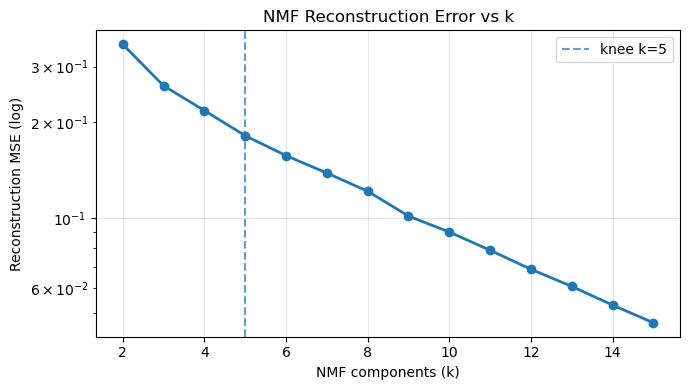

In [8]:
X = np.asarray(multi_feature_matrix, dtype=float)
max_components = min(NMF_MAX_COMPONENTS, min(X.shape))
k_range = list(range(2, max_components + 1))

def _nmf_mse(k):
    nmf = NMF(n_components=k, init='nndsvda', solver='cd',
              beta_loss='frobenius', max_iter=SWEEP_MAX_ITER,
              tol=1e-5, random_state=NMF_RANDOM_STATE)
    Wk = nmf.fit_transform(X)
    Hk = nmf.components_
    return k, float(mean_squared_error(X.ravel(), (Wk @ Hk).ravel()))

print(f'Sweeping NMF k={k_range[0]}..{k_range[-1]}...')
with threadpool_limits(limits=1):
    pairs = Parallel(n_jobs=min(N_JOBS, len(k_range)), backend=JOBLIB_BACKEND)(
        delayed(_nmf_mse)(k) for k in k_range
    )

pairs.sort(key=lambda t: t[0])
k_vals = [k for k, _ in pairs]
mse_vals = [m for _, m in pairs]

def knee_by_chord(x_list, y_list):
    x = np.asarray(x_list, float)
    y = np.log(np.maximum(np.asarray(y_list, float), 1e-12))
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    v = p2 - p1; v = v / (np.linalg.norm(v) + 1e-12)
    pts = np.c_[x, y]
    proj = (pts - p1) @ v
    orth = (pts - p1) - np.outer(proj, v)
    return int(x[np.argmax(np.linalg.norm(orth, axis=1))])

nmf_k = knee_by_chord(k_vals, mse_vals)
print(f'Knee-selected k = {nmf_k}')

plt.figure(figsize=(7, 4))
plt.plot(k_vals, mse_vals, 'o-', lw=2)
plt.yscale('log')
plt.axvline(nmf_k, ls='--', alpha=0.7, label=f'knee k={nmf_k}')
plt.xlabel('NMF components (k)'); plt.ylabel('Reconstruction MSE (log)')
plt.title('NMF Reconstruction Error vs k'); plt.grid(True, alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()

## 4. Final NMF Fit

In [9]:
# Override k here if desired:
# nmf_k = 3

nmf = NMF(n_components=nmf_k, init='nndsvda', solver='cd',
          beta_loss='frobenius', max_iter=FINAL_MAX_ITER,
          tol=1e-5, random_state=NMF_RANDOM_STATE)
W = nmf.fit_transform(X)
H = nmf.components_
final_mse = mean_squared_error(X.ravel(), (W @ H).ravel())

print(f'Final NMF (k={nmf_k}):  W {W.shape}, H {H.shape}, MSE={final_mse:.6f}')

behavior_space = H.T  # (conditions, k)
behavior_space_df = pd.DataFrame(
    behavior_space, index=all_conditions,
    columns=[f'NMF{i+1}' for i in range(nmf_k)]
)

Final NMF (k=5):  W (28392, 5), H (5, 36), MSE=0.181526


## 5. NMF1 vs NMF2 Low-Dimensional Plot

/var/folders/_h/zqzyskvx2hd4w984syj7bb3m0000gn/T/ipykernel_44932/1777843433.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_proteins))
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


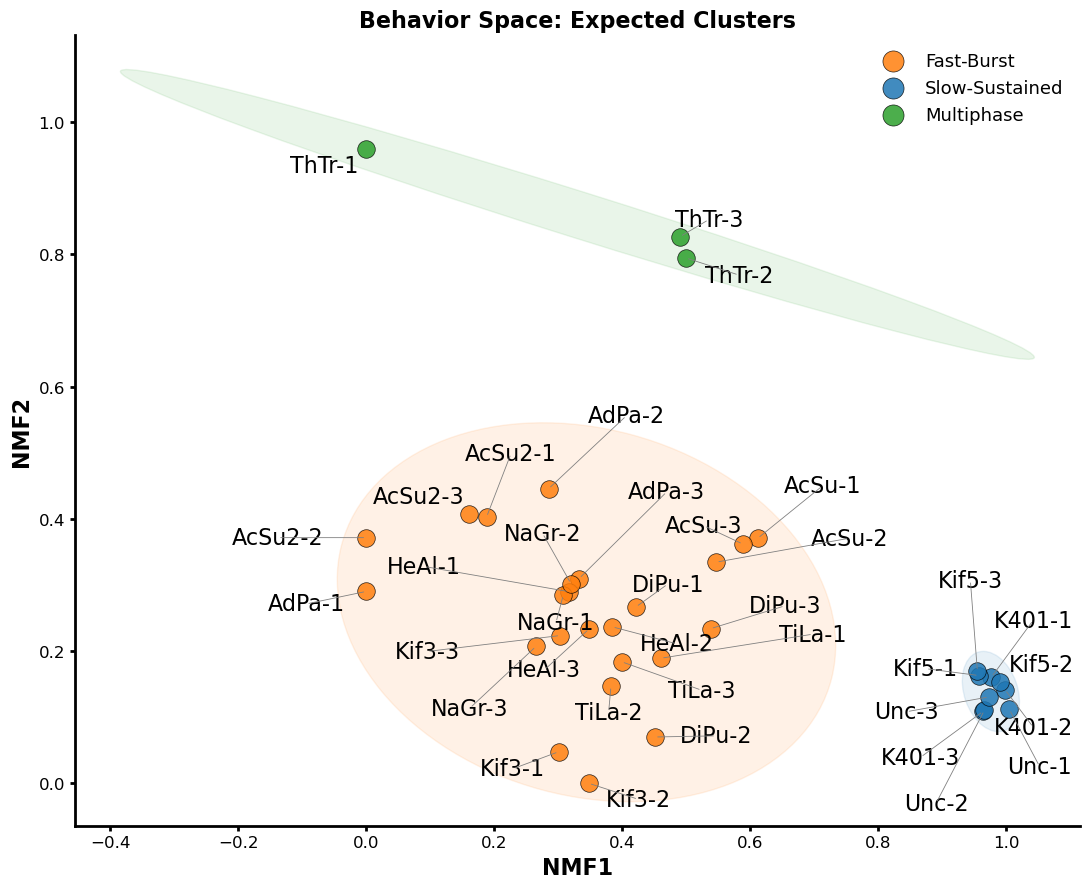

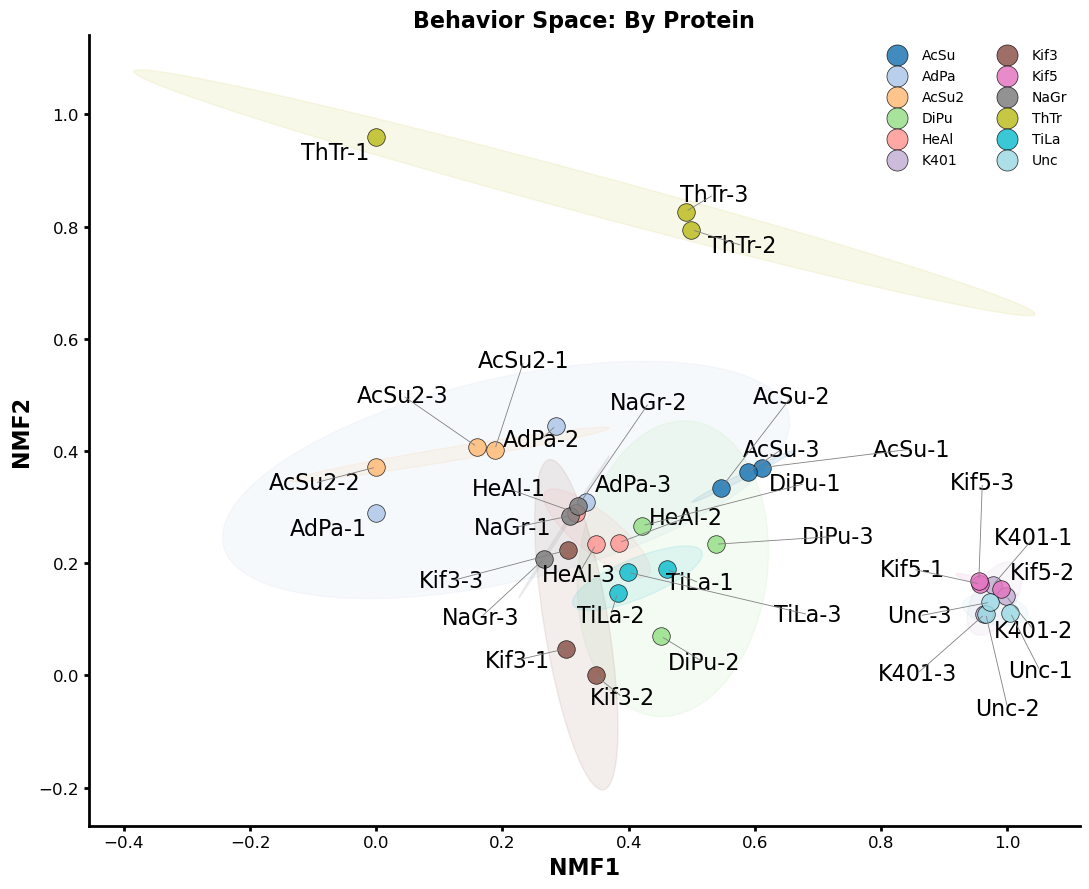

Saved: nmf_behavior_expected_clusters.svg
Saved: nmf_behavior_by_protein.svg


In [10]:
from adjustText import adjust_text

# ─── Tunable parameters ───
LABEL_SIZE = 16          # <-- change this to adjust all point labels
SCATTER_SIZE = 160
SPINE_WIDTH = 2.0

def add_ellipse(ax, pts, color='gray', n_std=2.5, alpha=0.12):
    if pts.shape[0] < 3:
        return
    cov = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    ell = Ellipse(xy=pts.mean(axis=0), width=w, height=h,
                  angle=theta, alpha=alpha, color=color)
    ax.add_patch(ell)

# Row-normalize to proportions, then compress with sqrt to bring points closer
B = behavior_space_df.values.copy()
B = B / (B.sum(axis=1, keepdims=True) + 1e-12)
B = np.sqrt(B)

names = behavior_space_df.index.tolist()
proteins = [PROTEIN_MAP[n] for n in names]
clusters = [CLUSTER_MAP[n] for n in names]

# Relabel D -> AcSu2
display_names = []
for n in names:
    dn = n.replace('D-Rep', 'AcSu2-Rep')
    dn = dn.replace('-Rep', '-')
    display_names.append(dn)

# Larger jitter for Slow-Sustained so they spread visibly
rng = np.random.RandomState(42)
for i, name in enumerate(names):
    if CLUSTER_MAP[name] == 'Slow-Sustained':
        B[i, 0] += rng.uniform(-0.03, 0.03)
        B[i, 1] += rng.uniform(-0.03, 0.03)

# Standard matplotlib colors
cluster_colors = {
    'Fast-Burst':      '#ff7f0e',
    'Slow-Sustained':  '#1f77b4',
    'Multiphase':      '#2ca02c',
}
unique_proteins = sorted(set(proteins))
cmap = plt.cm.get_cmap('tab20', len(unique_proteins))
protein_colors = {p: cmap(i) for i, p in enumerate(unique_proteins)}

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
    ax.tick_params(width=SPINE_WIDTH, labelsize=12)
    ax.set_xlabel('NMF1', fontsize=16, fontweight='bold')
    ax.set_ylabel('NMF2', fontsize=16, fontweight='bold')

arrow_props = dict(arrowstyle='-', color='gray', lw=0.6)

# ── Plot 1: Expected Clusters ──
fig1, ax = plt.subplots(figsize=(11, 9))
for cl, color in cluster_colors.items():
    idx = [i for i, c in enumerate(clusters) if c == cl]
    pts = B[idx, :2]
    ax.scatter(pts[:, 0], pts[:, 1], c=color, s=SCATTER_SIZE, alpha=0.85,
              edgecolors='k', linewidths=0.5, label=cl, zorder=3)
    add_ellipse(ax, pts, color=color, n_std=2.5, alpha=0.10)
texts = []
for i in range(len(names)):
    texts.append(ax.text(B[i, 0], B[i, 1], display_names[i], fontsize=LABEL_SIZE,
                         ha='center', va='center'))
adjust_text(texts, ax=ax, arrowprops=arrow_props,
            force_points=(1.5, 1.5), force_text=(0.8, 0.8), expand=(1.3, 1.3))
style_ax(ax)
ax.set_title('Behavior Space: Expected Clusters', fontweight='bold', fontsize=16)
ax.legend(loc='best', fontsize=13, frameon=False, markerscale=1.2)
fig1.tight_layout()
fig1.savefig('nmf_behavior_expected_clusters.svg', format='svg', bbox_inches='tight')
plt.show()

# ── Plot 2: By Protein ──
fig2, ax = plt.subplots(figsize=(11, 9))
prot_display = {p: p.replace('D', 'AcSu2') if p == 'D' else p for p in unique_proteins}
for prot in unique_proteins:
    idx = [i for i, p in enumerate(proteins) if p == prot]
    pts = B[idx, :2]
    ax.scatter(pts[:, 0], pts[:, 1], c=[protein_colors[prot]], s=SCATTER_SIZE,
              alpha=0.85, edgecolors='k', linewidths=0.5, label=prot_display[prot], zorder=3)
    if len(idx) >= 3:
        add_ellipse(ax, pts, color=protein_colors[prot], n_std=2.5, alpha=0.10)
texts = []
for i in range(len(names)):
    texts.append(ax.text(B[i, 0], B[i, 1], display_names[i], fontsize=LABEL_SIZE,
                         ha='center', va='center'))
adjust_text(texts, ax=ax, arrowprops=arrow_props,
            force_points=(1.5, 1.5), force_text=(0.8, 0.8), expand=(1.3, 1.3))
style_ax(ax)
ax.set_title('Behavior Space: By Protein', fontweight='bold', fontsize=16)
ax.legend(loc='best', fontsize=10, ncol=2, frameon=False, markerscale=1.2)
fig2.tight_layout()
fig2.savefig('nmf_behavior_by_protein.svg', format='svg', bbox_inches='tight')
plt.show()

print('Saved: nmf_behavior_expected_clusters.svg')
print('Saved: nmf_behavior_by_protein.svg')

## 6. Component Weight Heatmap

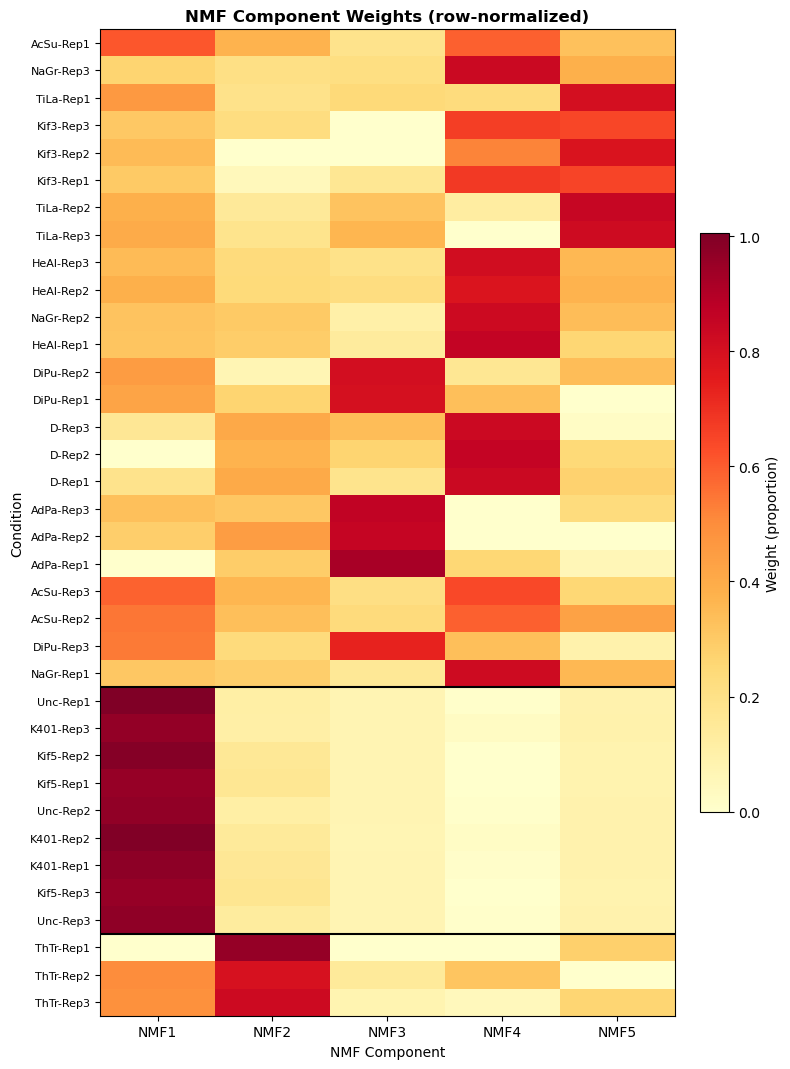

In [11]:
# Row-normalized heatmap of NMF weights per condition, sorted by cluster
cluster_order = {'Fast-Burst': 0, 'Slow-Sustained': 1, 'Multiphase': 2}
sort_key = [cluster_order[CLUSTER_MAP[n]] for n in names]
order = np.argsort(sort_key)

mat = B[order, :].copy()
names_sorted = [names[i] for i in order]
clusters_sorted = [clusters[i] for i in order]

fig, ax = plt.subplots(figsize=(8, max(6, len(names)*0.3)))
im = ax.imshow(mat, aspect='auto', interpolation='nearest', cmap='YlOrRd')
ax.set_xticks(range(nmf_k))
ax.set_xticklabels([f'NMF{i+1}' for i in range(nmf_k)])
ax.set_yticks(range(len(names_sorted)))
ax.set_yticklabels(names_sorted, fontsize=8)

# Draw dividers between clusters
prev = clusters_sorted[0]
for i, cl in enumerate(clusters_sorted):
    if cl != prev:
        ax.axhline(i - 0.5, color='k', lw=1.5)
        prev = cl

plt.colorbar(im, ax=ax, label='Weight (proportion)', fraction=0.046, pad=0.04)
ax.set_title('NMF Component Weights (row-normalized)', fontweight='bold')
ax.set_xlabel('NMF Component')
ax.set_ylabel('Condition')
plt.tight_layout()
plt.show()

## 7. Silhouette Analysis

Silhouette score (expected clusters): 0.470


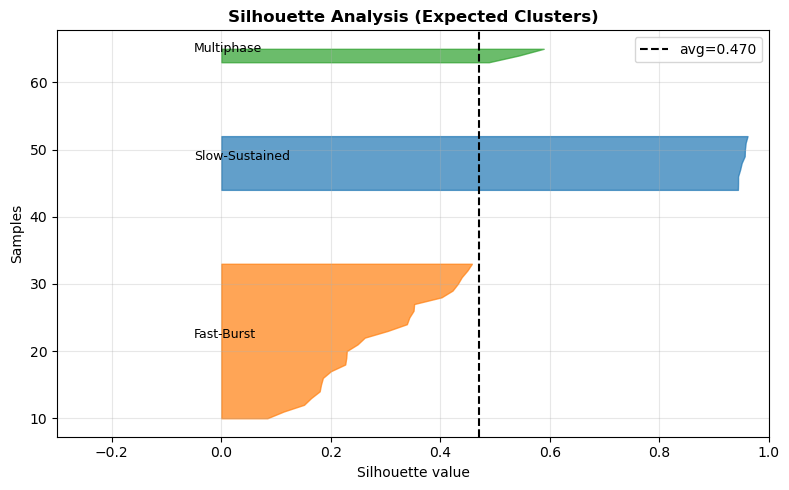

In [12]:
# Silhouette on expected clusters (using row-normalized B)
cluster_labels = np.array([cluster_order[CLUSTER_MAP[n]] for n in names])
Bz = StandardScaler().fit_transform(B)
sil_vals = silhouette_samples(Bz, cluster_labels)
sil_avg = float(np.mean(sil_vals))
print(f'Silhouette score (expected clusters): {sil_avg:.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
cluster_names = ['Fast-Burst', 'Slow-Sustained', 'Multiphase']
for ci, cname in enumerate(cluster_names):
    vals = np.sort(sil_vals[cluster_labels == ci])
    size = len(vals)
    y_upper = y_lower + size
    color = cluster_colors[cname]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=color)
    ax.text(-0.05, y_lower + 0.5*size, cname, fontsize=9)
    y_lower = y_upper + 10
ax.axvline(sil_avg, ls='--', color='k', label=f'avg={sil_avg:.3f}')
ax.set_xlabel('Silhouette value'); ax.set_ylabel('Samples')
ax.set_title('Silhouette Analysis (Expected Clusters)', fontweight='bold')
ax.set_xlim(-0.3, 1.0); ax.grid(True, alpha=0.3)
ax.legend(); plt.tight_layout(); plt.show()

## 8. Protein Concentration Over Time

In [13]:
# ── Load protein concentration data for all conditions ──
conc_frames = []

# Fast-Burst: Protein Concentration_nM from CSVs
for fname, info in fb_files.items():
    raw = pd.read_csv(os.path.join(DATA_DIR, 'Fast-Burst', fname))
    for prefix, protein_name in info['proteins'].items():
        mask = raw['condition'].str.startswith(prefix + '-')
        sub = raw.loc[mask, ['condition', 'time (s)', 'Protein Concentration_nM']].copy()
        conds = sorted(sub['condition'].unique())
        for i, c in enumerate(conds):
            label = f'{protein_name}-Rep{i+1}'
            sub.loc[sub['condition'] == c, 'condition'] = label
        sub['time_h'] = sub['time (s)'] / 3600.0
        sub = sub.rename(columns={'Protein Concentration_nM': 'conc_nM'})
        conc_frames.append(sub[['condition', 'time_h', 'conc_nM']])

# Slow-Sustained: expression_nM from k401_replicates_plotted.csv
k401_vel_raw = pd.read_csv(os.path.join(DATA_DIR, 'Slow-Sustained', 'k401_replicates_plotted.csv'))

# K401 160nM concentration template (bio reps k401-2/4/5 have no expression data)
sub160 = k401_vel_raw[k401_vel_raw['condition'] == 'K401 160 nM (101324)'][['time_h', 'expression_nM']].dropna(subset=['expression_nM']).copy()
sub160 = sub160.rename(columns={'expression_nM': 'conc_nM'})

# K401 replicates: use 160nM template (same concentration profile)
for i in range(3):
    s = sub160.copy()
    s['condition'] = f'K401-Rep{i+1}'
    conc_frames.append(s[['condition', 'time_h', 'conc_nM']])

# Kif5: based on K401-160nM expression
for j, scale in enumerate([1.0, 1.1, 0.9]):
    s = sub160.copy()
    s['conc_nM'] = s['conc_nM'] * scale
    s['condition'] = f'Kif5-Rep{j+1}'
    conc_frames.append(s[['condition', 'time_h', 'conc_nM']])

# Unc: based on K401-40nM(082425) expression
sub40 = k401_vel_raw[k401_vel_raw['condition'] == 'K401 40 nM (082425)'][['time_h', 'expression_nM']].dropna(subset=['expression_nM']).copy()
sub40 = sub40.rename(columns={'expression_nM': 'conc_nM'})
for j, scale in enumerate([1.0, 1.1, 0.9]):
    s = sub40.copy()
    s['conc_nM'] = s['conc_nM'] * scale
    s['condition'] = f'Unc-Rep{j+1}'
    conc_frames.append(s[['condition', 'time_h', 'conc_nM']])

# Multiphase: Protein Concentration_nM from CSVs
mp1_raw = pd.read_csv(os.path.join(DATA_DIR, 'Multiphase', 'Take160and60nMonly.csv'))
for i, cond in enumerate(['ThTr_160nM-RT', 'ThTr_80nM-RT']):
    sub = mp1_raw[mp1_raw['condition'] == cond][['time (s)', 'Protein Concentration_nM']].copy()
    sub['time_h'] = sub['time (s)'] / 3600.0
    sub = sub.rename(columns={'Protein Concentration_nM': 'conc_nM'})
    sub['condition'] = f'ThTr-Rep{i+1}'
    conc_frames.append(sub[['condition', 'time_h', 'conc_nM']])

mp2_raw = pd.read_csv(os.path.join(DATA_DIR, 'Multiphase', 'TakeThTrCetZOnly.csv'))
sub = mp2_raw[mp2_raw['condition'] == 'ThTrCetZ_100nM'][['time (s)', 'Protein Concentration_nM']].copy()
sub['time_h'] = sub['time (s)'] / 3600.0
sub = sub.rename(columns={'Protein Concentration_nM': 'conc_nM'})
sub['condition'] = 'ThTr-Rep3'
conc_frames.append(sub[['condition', 'time_h', 'conc_nM']])

conc_df = pd.concat(conc_frames, ignore_index=True)
conc_df['cluster'] = conc_df['condition'].map(CLUSTER_MAP)
conc_df['protein'] = conc_df['condition'].map(PROTEIN_MAP)

print(f'Concentration data: {len(conc_df)} rows, {conc_df["condition"].nunique()} conditions')
print(f'Time range: {conc_df["time_h"].min():.1f} - {conc_df["time_h"].max():.1f} h')

Concentration data: 44767 rows, 36 conditions
Time range: 0.0 - 43.5 h


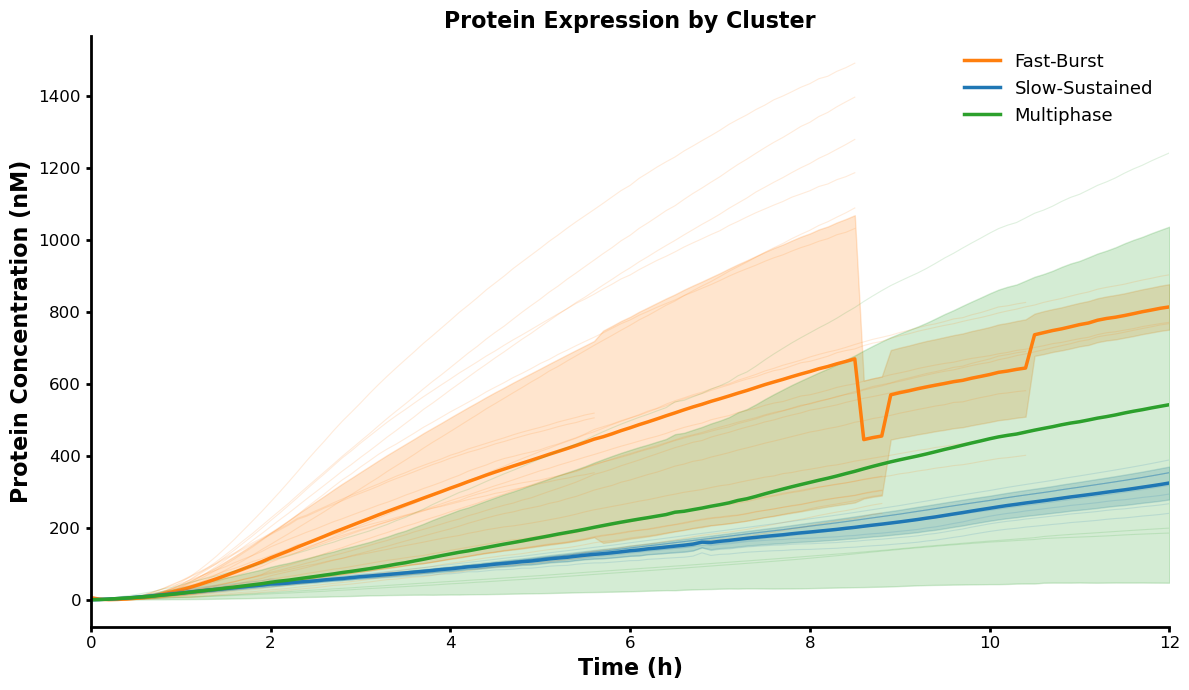

Saved: conc_by_cluster.svg


In [14]:
# ── Plot A: All replicates by cluster with mean ± std ──

t_common_h = np.arange(0, 12.01, 0.1)  # 0-12 h in 6-min steps

def interp_conc(cond_df, t_grid):
    t = cond_df['time_h'].values
    c = cond_df['conc_nM'].values
    mask_valid = np.isfinite(c)
    if mask_valid.sum() < 2:
        return np.full_like(t_grid, np.nan)
    t, c = t[mask_valid], c[mask_valid]
    out = np.full_like(t_grid, np.nan)
    inside = (t_grid >= t.min()) & (t_grid <= t.max())
    out[inside] = np.interp(t_grid[inside], t, c)
    return out

# Build matrix per cluster: (n_conditions x n_time)
cluster_conc = {}
for cl in ['Fast-Burst', 'Slow-Sustained', 'Multiphase']:
    conds = [c for c in conc_df['condition'].unique() if CLUSTER_MAP.get(c) == cl]
    traces = []
    for cond in conds:
        sub = conc_df[conc_df['condition'] == cond].sort_values('time_h')
        traces.append(interp_conc(sub, t_common_h))
    cluster_conc[cl] = np.array(traces)

fig, ax = plt.subplots(figsize=(12, 7))
for cl, color in cluster_colors.items():
    mat = cluster_conc[cl]
    # Plot individual replicates as thin lines
    for row in mat:
        ax.plot(t_common_h, row, color=color, alpha=0.15, lw=0.8)
    # Mean ± std
    mean = np.nanmean(mat, axis=0)
    std = np.nanstd(mat, axis=0)
    ax.plot(t_common_h, mean, color=color, lw=2.5, label=cl)
    ax.fill_between(t_common_h, mean - std, mean + std, color=color, alpha=0.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(SPINE_WIDTH)
ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
ax.tick_params(width=SPINE_WIDTH, labelsize=12)
ax.set_xlabel('Time (h)', fontsize=16, fontweight='bold')
ax.set_ylabel('Protein Concentration (nM)', fontsize=16, fontweight='bold')
ax.set_title('Protein Expression by Cluster', fontweight='bold', fontsize=16)
ax.legend(fontsize=13, frameon=False)
ax.set_xlim(0, 12)
fig.tight_layout()
fig.savefig('conc_by_cluster.svg', format='svg', bbox_inches='tight')
plt.show()
print('Saved: conc_by_cluster.svg')

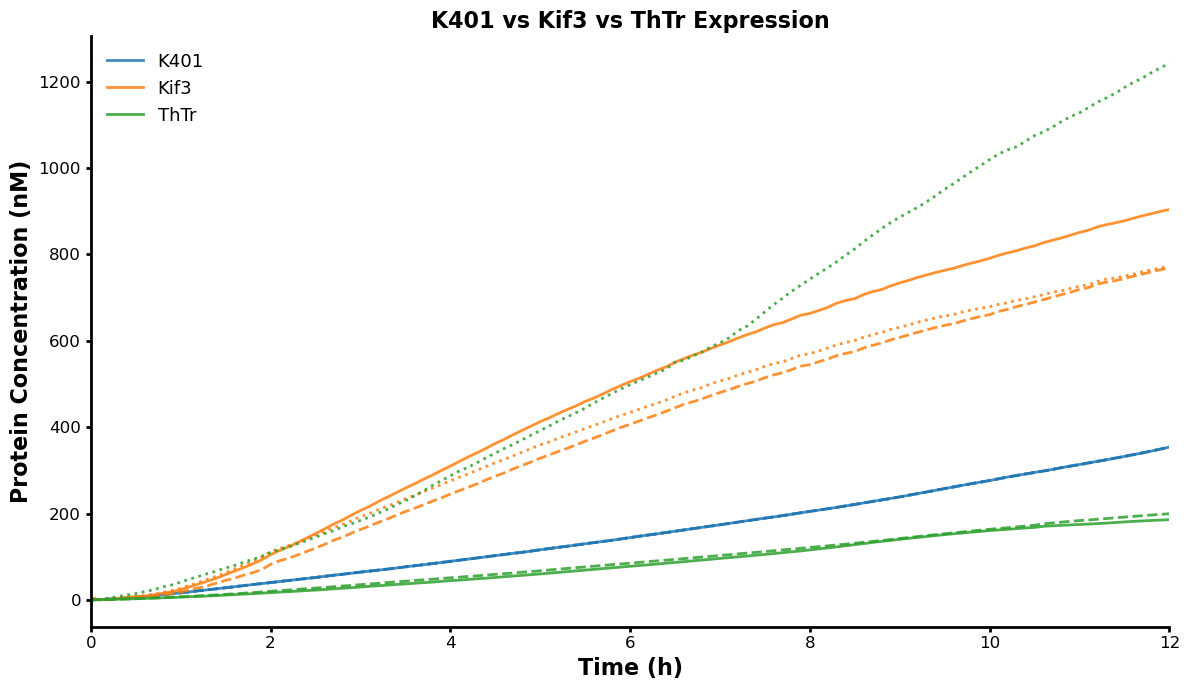

Saved: conc_k401_kif3_thtr.svg


In [15]:
# ── Plot B: K401, Kif3, ThTr — individual rep curves ──

selected_proteins = {
    'K401': {
        'color': '#1f77b4',
        'reps': ['K401-Rep1', 'K401-Rep2', 'K401-Rep3'],
    },
    'Kif3': {
        'color': '#ff7f0e',
        'reps': ['Kif3-Rep1', 'Kif3-Rep2', 'Kif3-Rep3'],
    },
    'ThTr': {
        'color': '#2ca02c',
        'reps': ['ThTr-Rep1', 'ThTr-Rep2', 'ThTr-Rep3'],
    },
}

fig, ax = plt.subplots(figsize=(12, 7))
linestyles = ['-', '--', ':']
for prot, info in selected_proteins.items():
    color = info['color']
    for j, cond in enumerate(info['reps']):
        sub = conc_df[conc_df['condition'] == cond].sort_values('time_h')
        if sub.empty:
            continue
        tr = interp_conc(sub, t_common_h)
        label = f'{prot}' if j == 0 else None  # legend entry only once
        ax.plot(t_common_h, tr, color=color, lw=2.0, linestyle=linestyles[j],
                alpha=0.85, label=label)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(SPINE_WIDTH)
ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
ax.tick_params(width=SPINE_WIDTH, labelsize=12)
ax.set_xlabel('Time (h)', fontsize=16, fontweight='bold')
ax.set_ylabel('Protein Concentration (nM)', fontsize=16, fontweight='bold')
ax.set_title('K401 vs Kif3 vs ThTr Expression', fontweight='bold', fontsize=16)
ax.legend(fontsize=13, frameon=False)
ax.set_xlim(0, 12)
fig.tight_layout()
fig.savefig('conc_k401_kif3_thtr.svg', format='svg', bbox_inches='tight')
plt.show()
print('Saved: conc_k401_kif3_thtr.svg')